In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
df = pd.read_csv(r'C:\Users\ammar\Desktop\hotel_bookings.csv')

In [17]:
print(df.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [18]:

print("--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n----------------------")

print("--- Duplicated Rows ---")
print(df.duplicated().sum())

--- Missing Values ---
children         4
country        488
agent        16340
company     112593
dtype: int64

----------------------
--- Duplicated Rows ---
31994


In [19]:

df.drop_duplicates(inplace=True)

df['children'].fillna(0, inplace=True)
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)


df['country'].fillna('Unknown', inplace=True)


print("Remaining Missing Values:")
print(df.isnull().sum().sum())
print("\nRemaining Duplicates:")
print(df.duplicated().sum())

Remaining Missing Values:
0

Remaining Duplicates:
0


In [20]:

print("Total Missing Values Left:", df.isnull().sum().sum())
print("Total Duplicated Rows Left:", df.duplicated().sum())
print("New Data Shape:", df.shape)

Total Missing Values Left: 0
Total Duplicated Rows Left: 0
New Data Shape: (87396, 32)


In [21]:
# نسبة الحجوزات الملغاة المؤكدة في الفندق
print("--- Cancellation Rate ---")
print(df['is_canceled'].value_counts(normalize=True) * 100)

print("\n----------------------")

# أي نوع فندق يحقق حجوزات أكثر
print("--- Bookings by Hotel Type ---")
print(df['hotel'].value_counts())

--- Cancellation Rate ---
is_canceled
0    72.510184
1    27.489816
Name: proportion, dtype: float64

----------------------
--- Bookings by Hotel Type ---
hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64


In [22]:
# مقارنة إلغاء الحجوزات بين االفنادق و المنتجعات

print("--- Cancellations by Hotel Type ---")
print(pd.crosstab(df['hotel'], df['is_canceled'], normalize='index') * 100)

print("\n----------------------")

# أعلى 10 دول بيجي منها عملاء للفنادق دي

print("--- Top 10 Countries ---")
print(df['country'].value_counts().head(10))

--- Cancellations by Hotel Type ---
is_canceled           0          1
hotel                             
City Hotel    69.961443  30.038557
Resort Hotel  76.519077  23.480923

----------------------
--- Top 10 Countries ---
country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64


In [23]:
# ترتيب الشهور من الأكثر حجوزاً للأقل
print("--- Busy Months ---")
print(df['arrival_date_month'].value_counts())

print("\n----------------------")

#   (ADR) لكل نوع فندق متوسط سعر الغرفة اليومي
print("--- Average ADR by Hotel Type ---")
print(df.groupby('hotel')['adr'].mean())

--- Busy Months ---
arrival_date_month
August       11257
July         10057
May           8355
April         7908
June          7765
March         7513
October       6934
September     6690
February      6098
December      5131
November      4995
January       4693
Name: count, dtype: int64

----------------------
--- Average ADR by Hotel Type ---
hotel
City Hotel      110.985944
Resort Hotel     99.025346
Name: adr, dtype: float64


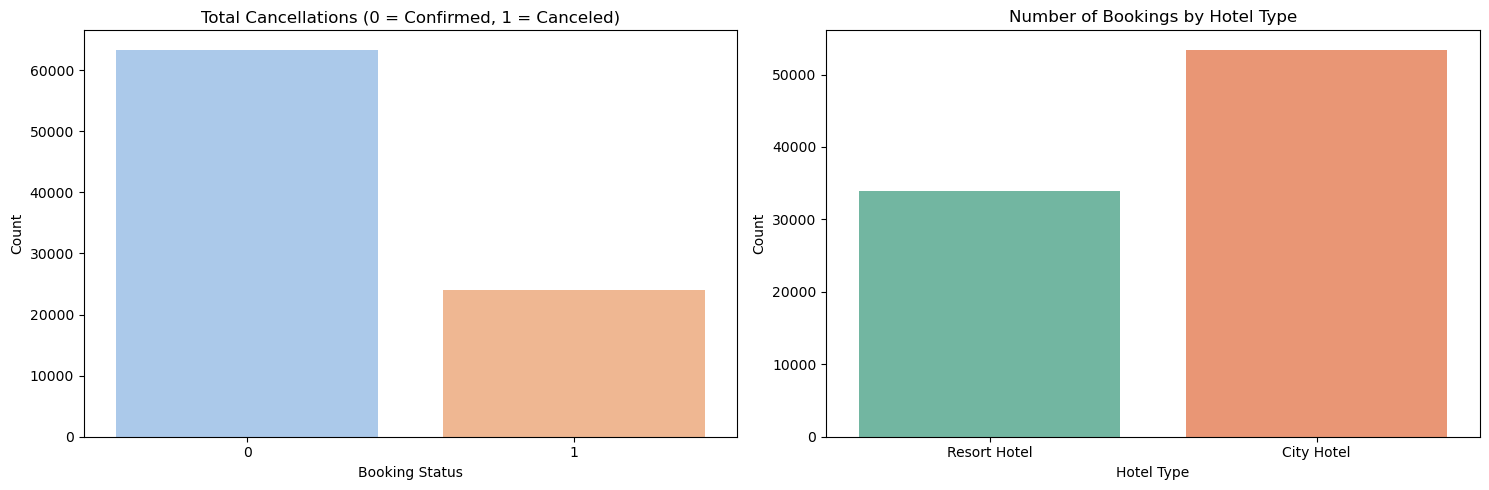

In [24]:
# تظبيط شكل وحجم الرسومات
plt.figure(figsize=(15, 5))

# الرسمة الأولى: نسبة الإلغاءات في الداتا كلها
plt.subplot(1, 2, 1)
sns.countplot(x='is_canceled', data=df, palette='pastel')
plt.title('Total Cancellations (0 = Confirmed, 1 = Canceled)')
plt.xlabel('Booking Status')
plt.ylabel('Count')

# الرسمة الثانية: مقارنة حجم الحجوزات بين نوعين الفنادق
plt.subplot(1, 2, 2)
sns.countplot(x='hotel', data=df, palette='Set2')
plt.title('Number of Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

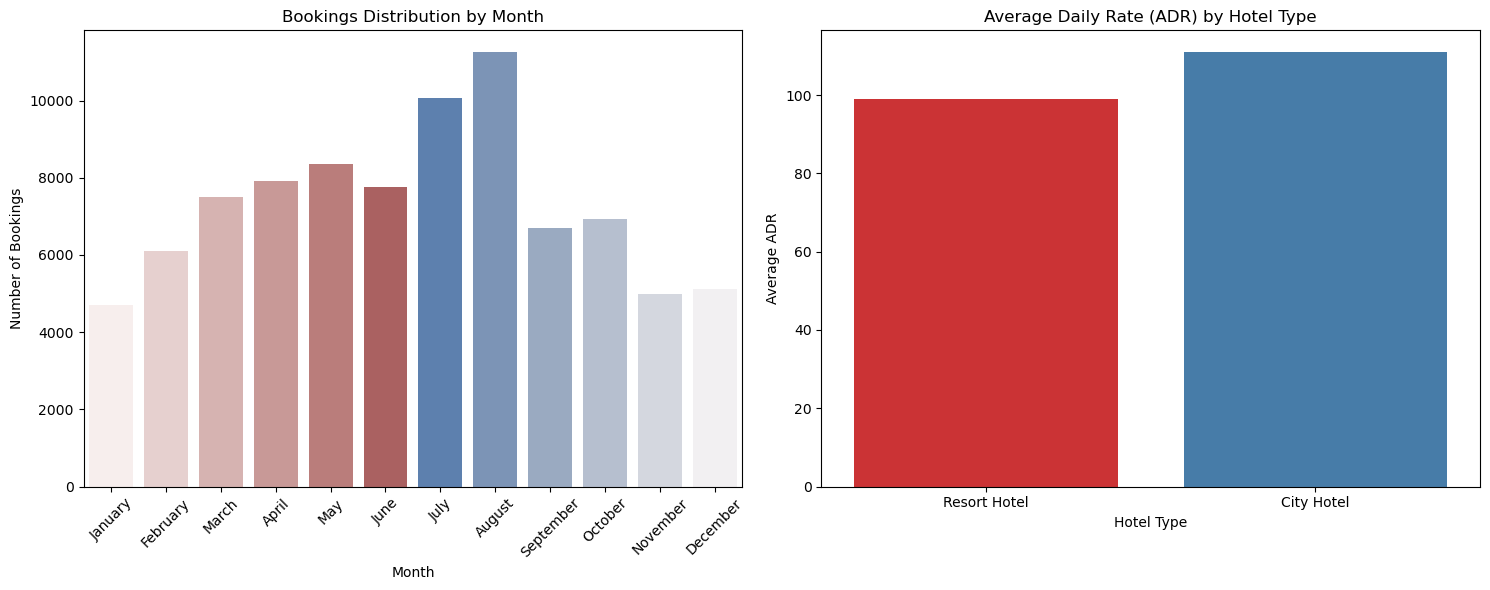

In [25]:
plt.figure(figsize=(15, 6))

# الرسمة الثالثة: خط سير الحجوزات عبر شهور السنة (Monthly Trend)
# رتبنا الشهور هنا ترتيب زمني عشان الرسمة تطلع مظبوطة
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

plt.subplot(1, 2, 1)
sns.countplot(x='arrival_date_month', data=df, order=months_order, hue='arrival_date_month', legend=False, palette='vlag')
plt.title('Bookings Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45) # عشان أسماء الشهور المائلة تظهر واضحة وميتداخلوش

# الرسمة الرابعة: متوسط سعر الغرفة (ADR) لكل نوع فندق
plt.subplot(1, 2, 2)
sns.barplot(x='hotel', y='adr', data=df, hue='hotel', legend=False, palette='Set1', errorbar=None)
plt.title('Average Daily Rate (ADR) by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average ADR')

plt.tight_layout()
plt.show()

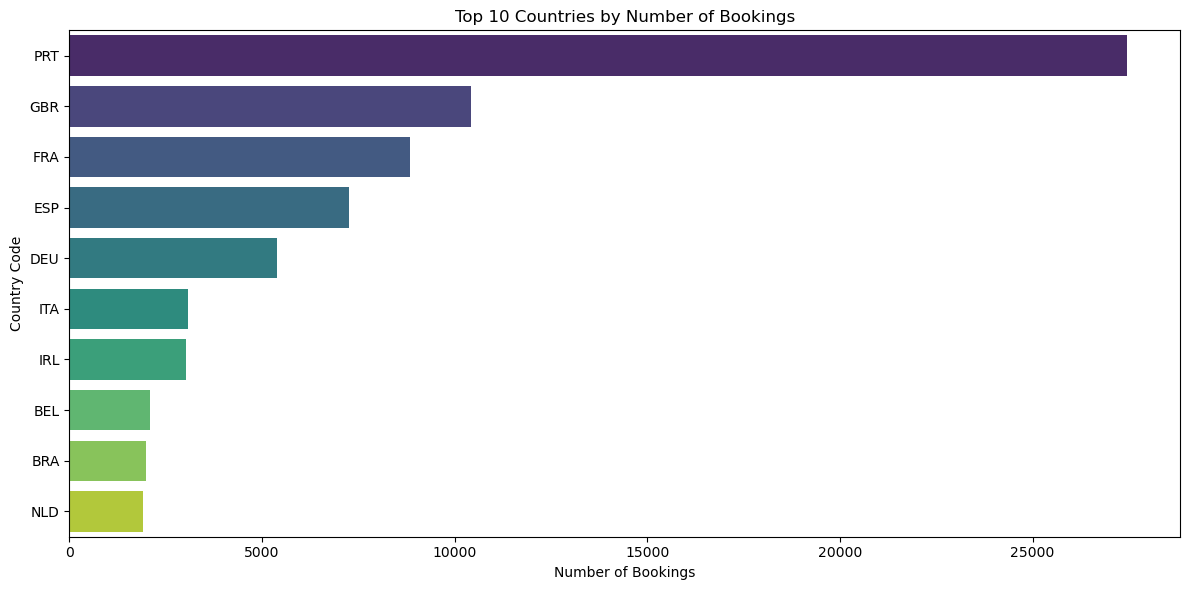

In [26]:
plt.figure(figsize=(12, 6))

# هنجهز داتا أعلى 10 دول
top_10_countries = df['country'].value_counts().head(10).reset_index()

# رسمة Barplot صايعة
sns.barplot(x='count', y='country', data=top_10_countries, hue='country', legend=False, palette='viridis')

plt.title('Top 10 Countries by Number of Bookings')
plt.xlabel('Number of Bookings')
plt.ylabel('Country Code')

plt.tight_layout()
plt.show()

## 📊 Executive Summary & Business Insights

### 1. Booking & Cancellation Patterns
* **Cancellation Alert:** The overall cancellation rate is **27.5%**, meaning nearly 3 out of 10 bookings are canceled. Management needs to review the cancellation policy or consider non-refundable deposits during peak seasons.
* **City vs. Resort:** **City Hotels** generate significantly more bookings (**53k+**) compared to **Resort Hotels** (**33k+**). However, City Hotels also suffer from a higher cancellation rate (**30%**) than Resort Hotels (**23.5%**).

### 2. Revenue & Seasonality Analysis
* **Peak Season:** **August** and **July** are the absolute peak months for hotel demand, while **January** represents the lowest trough. Marketing campaigns should focus on boosting off-peak months (Winter season).
* **Pricing Strategy (ADR):** **City Hotels** command a higher Average Daily Rate (**~$111**) compared to **Resort Hotels** (**~$99**). This indicates that urban properties are highly profitable on a per-night basis despite having shorter stays.

### 3. Geographical Insights
* **Top Market:** **Portugal (PRT)** is the dominant market leading with over **27k bookings**, followed by the UK (GBR) and France (FRA). International marketing budget should be heavily allocated to these top European destinations.
*